In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:

df = pd.read_csv('/content/Students_Social_Media_Addiction.csv.csv')

df

,Student_ID,Age,Gender,Academic_Level,Country,Avg_Daily_Usage_Hours,Most_Used_Platform,Affects_Academic_Performance,Sleep_Hours_Per_Night,Mental_Health_Score,Relationship_Status,Conflicts_Over_Social_Media,Addicted_Score,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Weekend_Usage_Hours
0,1,19,F,Undergraduate,Bangladesh,5.2,Instagram,Yes,6.5,96.0,In Relationship,3,8,4.1,7.1,Average,6.5
1,2,22,M,Graduate,India,2.1,Twitter,No,7.5,69.0,Single,0,3,3.3,5.2,Average,4.7
2,3,20,F,Undergraduate,USA,6.0,TikTok,Yes,5.0,86.0,Complicated,4,9,4.3,8.3,Average,6.9
3,4,18,M,High School,UK,3.0,YouTube,No,7.0,74.0,Single,1,4,5.3,4.4,Good,7.1
4,5,21,M,Graduate,Canada,4.5,Facebook,Yes,6.0,58.0,In Relationship,2,7,3.2,8.2,NaN,4.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
700,701,20,F,Undergraduate,Italy,4.7,TikTok,No,7.2,NaN,In Relationship,2,5,2.9,5.7,Good,4.7
701,702,23,M,Graduate,Russia,6.8,Instagram,Yes,5.9,66.0,Single,5,9,4.8,5.1,Good,7.1
702,703,21,F,Undergraduate,China,5.6,WeChat,Yes,6.7,79.0,In Relationship,3,7,2.7,8.0,Average,4.5
703,704,24,M,Graduate,Japan,4.3,Twitter,No,7.5,75.0,Single,2,4,1.8,6.2,Good,4.5


In [ ]:
df['Student_ID'].duplicated().sum()

np.int64(0)

In [ ]:
df.info()

df.isnull().sum()

df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 705 entries, 0 to 704
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Student_ID                    705 non-null    int64  
 1   Age                           705 non-null    int64  
 2   Gender                        705 non-null    object 
 3   Academic_Level                705 non-null    object 
 4   Country                       705 non-null    object 
 5   Avg_Daily_Usage_Hours         705 non-null    float64
 6   Most_Used_Platform            705 non-null    object 
 7   Affects_Academic_Performance  705 non-null    object 
 8   Sleep_Hours_Per_Night         705 non-null    float64
 9   Mental_Health_Score           635 non-null    float64
 10  Relationship_Status           705 non-null    object 
 11  Conflicts_Over_Social_Media   705 non-null    int64  
 12  Addicted_Score                705 non-null    int64  
 13  Daily

In [ ]:
df.isnull().sum()


,0
Student_ID,0
Age,0
Gender,0
Academic_Level,0
Country,0
Avg_Daily_Usage_Hours,0
Most_Used_Platform,0
Affects_Academic_Performance,0
Sleep_Hours_Per_Night,0
Mental_Health_Score,70


In [ ]:
df.describe()

,Student_ID,Age,Avg_Daily_Usage_Hours,Sleep_Hours_Per_Night,Mental_Health_Score,Conflicts_Over_Social_Media,Addicted_Score,Daily_Usage_Hours,Sleep_Hours,Weekend_Usage_Hours
count,705.000000,705.000000,705.000000,705.000000,635.000000,705.000000,705.000000,635.000000,635.000000,705.000000
mean,353.000000,21.056738,4.918723,6.868936,69.355906,2.849645,6.436879,3.477795,6.590551,5.261702
std,203.660256,2.276901,1.257395,1.126848,17.320033,0.957968,1.587165,1.179061,0.990733,1.402092
min,1.000000,18.000000,1.500000,3.800000,40.000000,0.000000,2.000000,0.300000,3.700000,1.300000
25%,177.000000,20.000000,4.100000,6.000000,54.000000,2.000000,5.000000,2.600000,5.900000,4.400000
50%,353.000000,21.000000,4.800000,6.900000,69.000000,3.000000,7.000000,3.500000,6.600000,5.200000
75%,529.000000,22.000000,5.800000,7.700000,84.000000,4.000000,8.000000,4.250000,7.200000,6.200000
max,705.000000,32.000000,8.500000,9.600000,99.000000,5.000000,9.000000,8.100000,9.100000,10.800000


In [ ]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns
cat_cols = df.select_dtypes(include="object").columns

print(num_cols)
print(cat_cols)


Index(['Student_ID', 'Age', 'Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night',
       'Mental_Health_Score', 'Conflicts_Over_Social_Media', 'Addicted_Score',
       'Daily_Usage_Hours', 'Sleep_Hours', 'Weekend_Usage_Hours'],
      dtype='object')
Index(['Gender', 'Academic_Level', 'Country', 'Most_Used_Platform',
       'Affects_Academic_Performance', 'Relationship_Status',
       'Academic_Performance'],
      dtype='object')


In [ ]:

df['Mental_Health_Score'] = df['Mental_Health_Score'].fillna(df['Mental_Health_Score'].mean())

df['Daily_Usage_Hours'] = df['Daily_Usage_Hours'].fillna(df['Daily_Usage_Hours'].mode())

df['Sleep_Hours'] = df['Sleep_Hours'].fillna(df['Sleep_Hours'].median())

df['Academic_Performance'] = df['Academic_Performance'].fillna(method='ffill')

/tmp/ipython-input-41563852.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Academic_Performance'] = df['Academic_Performance'].fillna(method='ffill')


In [ ]:
# drop_cols = [
#    "Student_ID",
 #   "Avg_Daily_Usage_Hours",
 #   "Relationship_Status"
#]

#df.drop(columns=drop_cols, inplace=True)


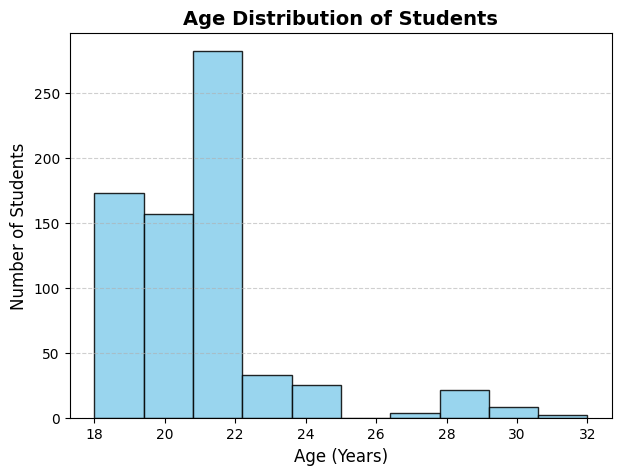

In [ ]:
plt.figure(figsize=(7,5))

plt.hist(
    df['Age'],
    bins=10,
    color='skyblue',
    edgecolor='black',
    alpha=0.85
)

plt.title("Age Distribution of Students", fontsize=14, fontweight='bold')
plt.xlabel("Age (Years)", fontsize=12)
plt.ylabel("Number of Students", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.show()


/tmp/ipython-input-1389371021.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


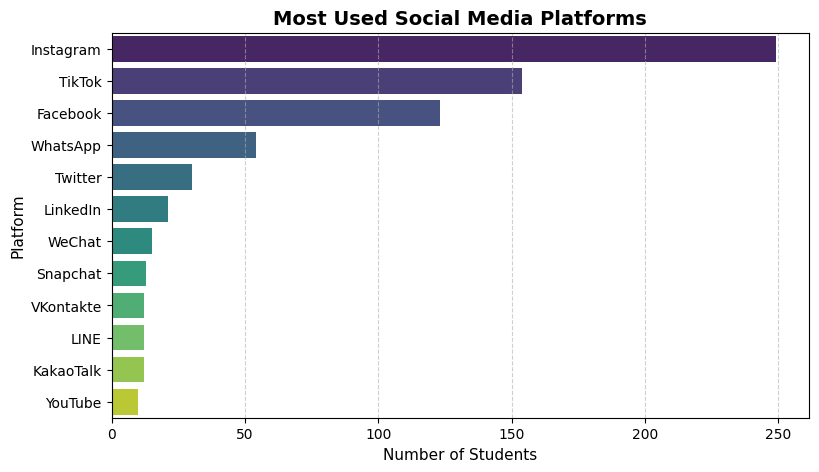

In [ ]:
plt.figure(figsize=(9,5))

sns.countplot(
    y=df["Most_Used_Platform"],
    order=df["Most_Used_Platform"].value_counts().index,
    palette="viridis"
)

plt.title("Most Used Social Media Platforms", fontsize=14, fontweight="bold")
plt.xlabel("Number of Students", fontsize=11)
plt.ylabel("Platform", fontsize=11)

plt.grid(axis="x", linestyle="--", alpha=0.6)
plt.show()


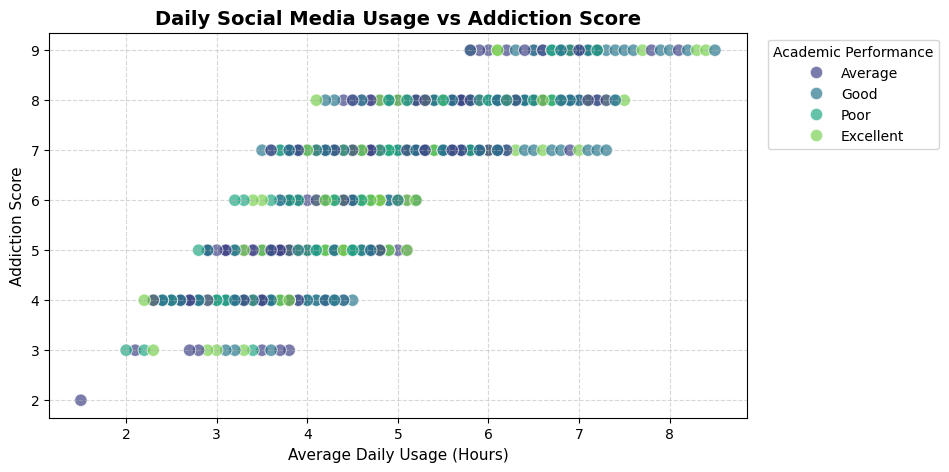

In [ ]:
plt.figure(figsize=(9,5))

sns.scatterplot(
    data=df,
    x="Avg_Daily_Usage_Hours",
    y="Addicted_Score",
    hue="Academic_Performance",   # adds insight
    palette="viridis",
    alpha=0.7,
    s=80
)

plt.title("Daily Social Media Usage vs Addiction Score",
          fontsize=14, fontweight="bold")
plt.xlabel("Average Daily Usage (Hours)", fontsize=11)
plt.ylabel("Addiction Score", fontsize=11)

plt.legend(title="Academic Performance", bbox_to_anchor=(1.02, 1))
plt.grid(True, linestyle="--", alpha=0.5)

plt.show()



/tmp/ipython-input-3105532840.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


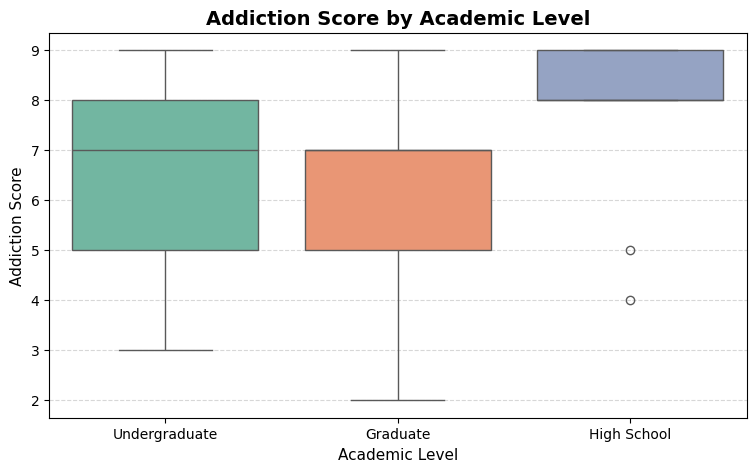

In [ ]:
plt.figure(figsize=(9,5))

sns.boxplot(
    data=df,
    x="Academic_Level",
    y="Addicted_Score",
    palette="Set2"
)

plt.title("Addiction Score by Academic Level",
          fontsize=14, fontweight="bold")
plt.xlabel("Academic Level", fontsize=11)
plt.ylabel("Addiction Score", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()


/tmp/ipython-input-999066066.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.barplot(
/tmp/ipython-input-999066066.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


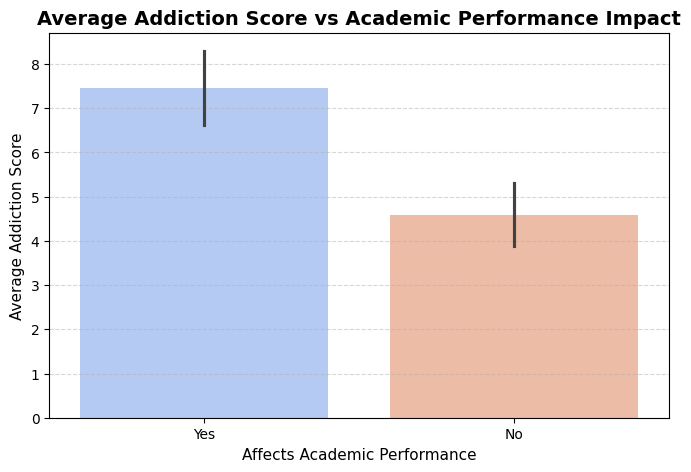

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=df,
    x="Affects_Academic_Performance",
    y="Addicted_Score",
    palette="coolwarm",
    ci="sd"
)

plt.title("Average Addiction Score vs Academic Performance Impact",
          fontsize=14, fontweight="bold")
plt.xlabel("Affects Academic Performance", fontsize=11)
plt.ylabel("Average Addiction Score", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()



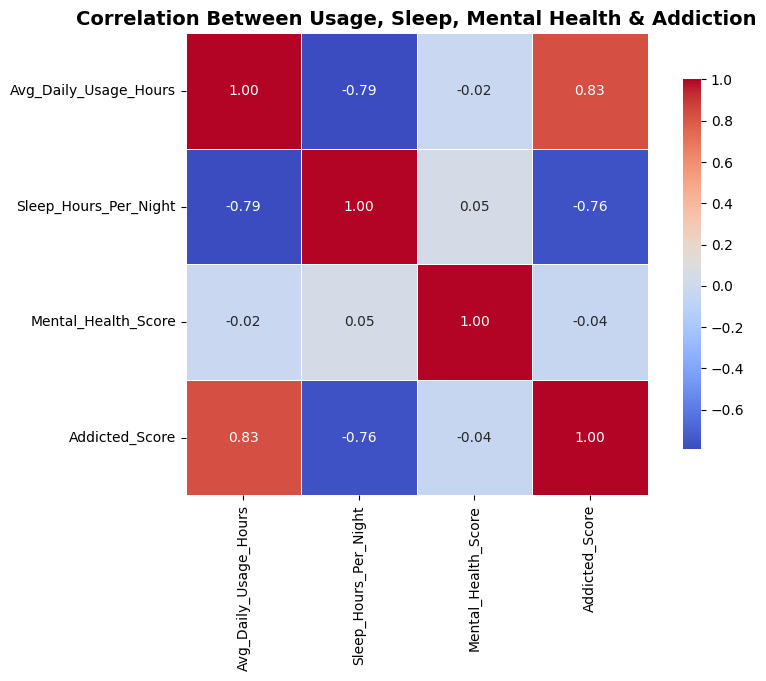

In [ ]:
plt.figure(figsize=(9,6))

corr = df[
    ["Avg_Daily_Usage_Hours",
     "Sleep_Hours_Per_Night",
     "Mental_Health_Score",
     "Addicted_Score"]
].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": 0.8}
)

plt.title("Correlation Between Usage, Sleep, Mental Health & Addiction",
          fontsize=14, fontweight="bold")
plt.show()



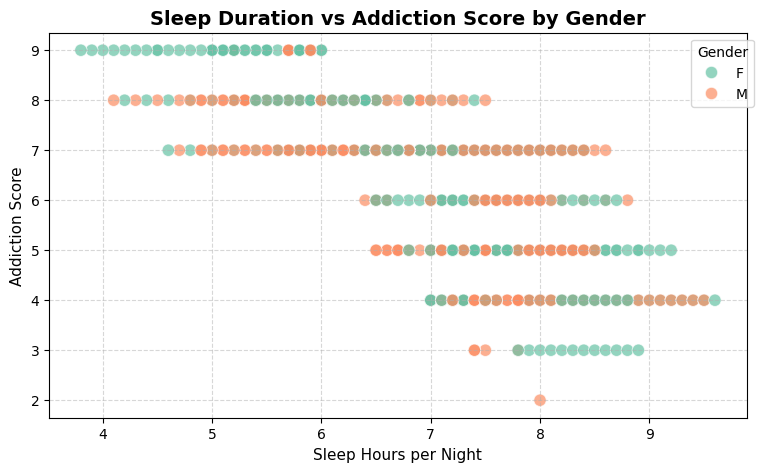

In [ ]:
plt.figure(figsize=(9,5))

sns.scatterplot(
    data=df,
    x="Sleep_Hours_Per_Night",
    y="Addicted_Score",
    hue="Gender",
    palette="Set2",
    alpha=0.7,
    s=80
)

plt.title("Sleep Duration vs Addiction Score by Gender",
          fontsize=14, fontweight="bold")
plt.xlabel("Sleep Hours per Night", fontsize=11)
plt.ylabel("Addiction Score", fontsize=11)

plt.legend(title="Gender", bbox_to_anchor=(1.02, 1))
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


/tmp/ipython-input-2002641933.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


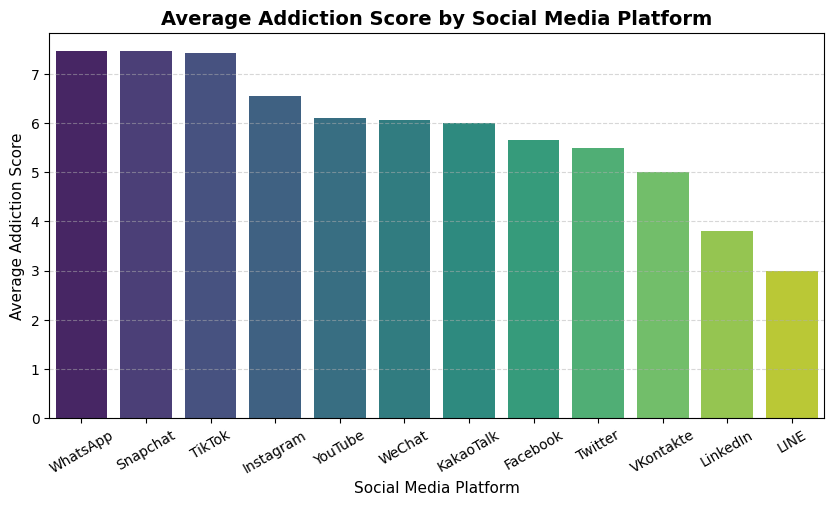

In [ ]:
# Which platform has the highest average Addicted Score?


platform_addiction = (
    df.groupby("Most_Used_Platform")["Addicted_Score"]
      .mean()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=platform_addiction.index,
    y=platform_addiction.values,
    palette="viridis"
)

plt.title("Average Addiction Score by Social Media Platform",
          fontsize=14, fontweight="bold")
plt.xlabel("Social Media Platform", fontsize=11)
plt.ylabel("Average Addiction Score", fontsize=11)

plt.xticks(rotation=30)
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.show()


/tmp/ipython-input-1771322251.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


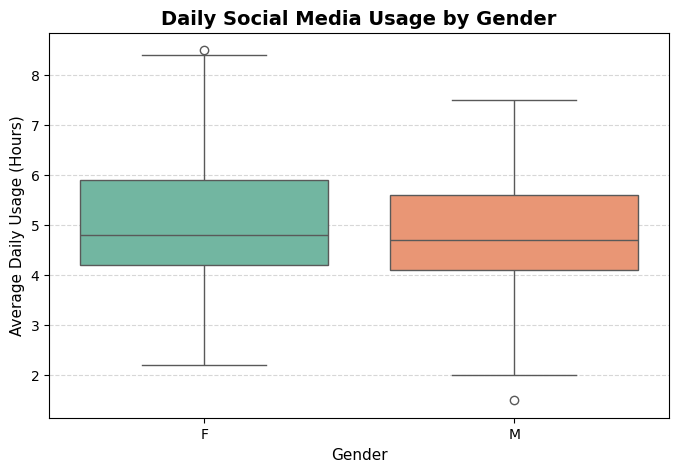

In [ ]:
#  Difference in daily usage hours between Male & Female students?

plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Gender",
    y="Avg_Daily_Usage_Hours",
    palette="Set2"
)

plt.title("Daily Social Media Usage by Gender",
          fontsize=14, fontweight="bold")
plt.xlabel("Gender", fontsize=11)
plt.ylabel("Average Daily Usage (Hours)", fontsize=11)

plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()



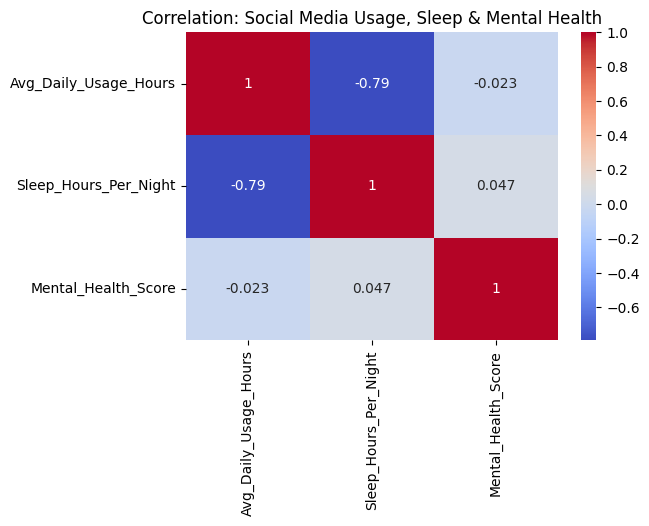

In [ ]:
# Correlation between usage, sleep, and mental health?

corr_data = df[['Avg_Daily_Usage_Hours', 'Sleep_Hours_Per_Night', 'Mental_Health_Score']].corr()

plt.figure(figsize=(6,4))
sns.heatmap(
    corr_data,
    annot=True,
    cmap='coolwarm',
)
plt.title("Correlation: Social Media Usage, Sleep & Mental Health")
plt.show()


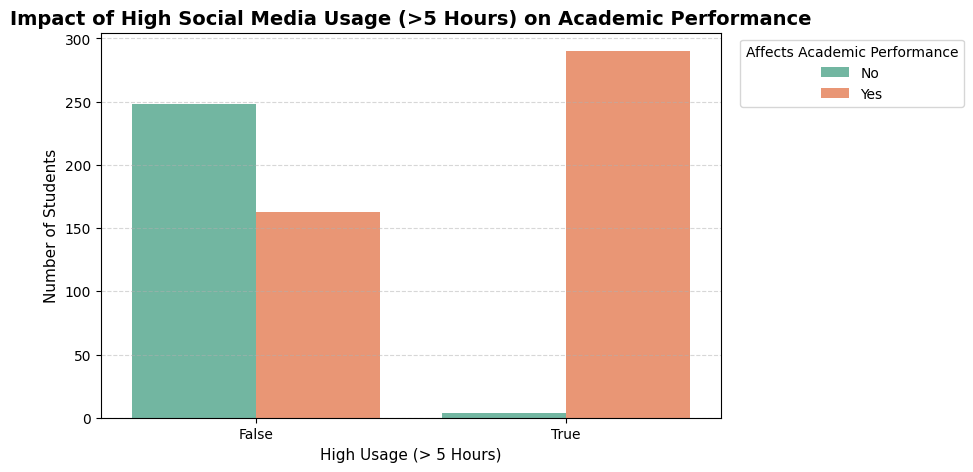

In [ ]:
# Does >5 hours usage affect academics?

# Create High Usage flag
df["High_Usage"] = df["Avg_Daily_Usage_Hours"] > 5

plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="High_Usage",
    hue="Affects_Academic_Performance",
    palette="Set2"
)

plt.title("Impact of High Social Media Usage (>5 Hours) on Academic Performance",
          fontsize=14, fontweight="bold")
plt.xlabel("High Usage (> 5 Hours)", fontsize=11)
plt.ylabel("Number of Students", fontsize=11)

plt.legend(title="Affects Academic Performance", bbox_to_anchor=(1.02, 1))
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.show()



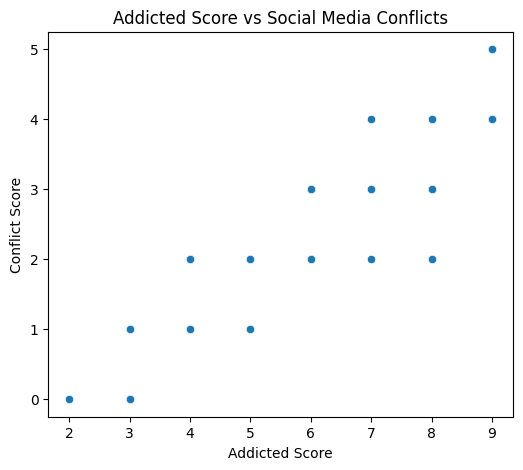

In [ ]:
# Does addiction lead to more conflicts?

plt.figure(figsize=(6,5))
sns.scatterplot(
    x='Addicted_Score',
    y='Conflicts_Over_Social_Media',
    data=df
)
plt.title("Addicted Score vs Social Media Conflicts")
plt.xlabel("Addicted Score")
plt.ylabel("Conflict Score")
plt.show()


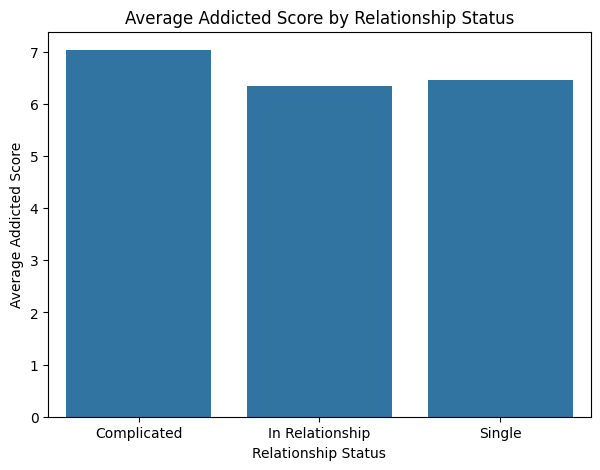

In [ ]:
# Does relationship status affect addiction?

relationship_addiction = df.groupby('Relationship_Status')['Addicted_Score'].mean()

plt.figure(figsize=(7,5))
sns.barplot(
    x=relationship_addiction.index,
    y=relationship_addiction.values
)
plt.title("Average Addicted Score by Relationship Status")
plt.xlabel("Relationship Status")
plt.ylabel("Average Addicted Score")
plt.show()
